In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [77]:
df = pd.read_csv("CarPrice_Assignment.csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [78]:
print("Shape:", df.shape)

df.info()

Shape: (205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-n

In [79]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [80]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [81]:
df.drop("car_ID", axis=1, inplace=True)

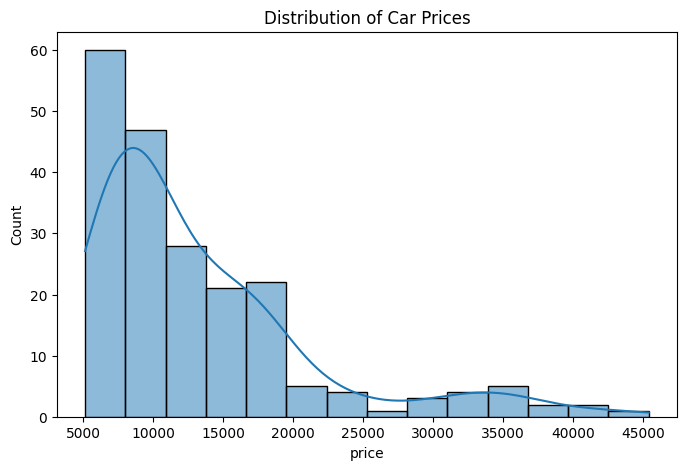

In [82]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

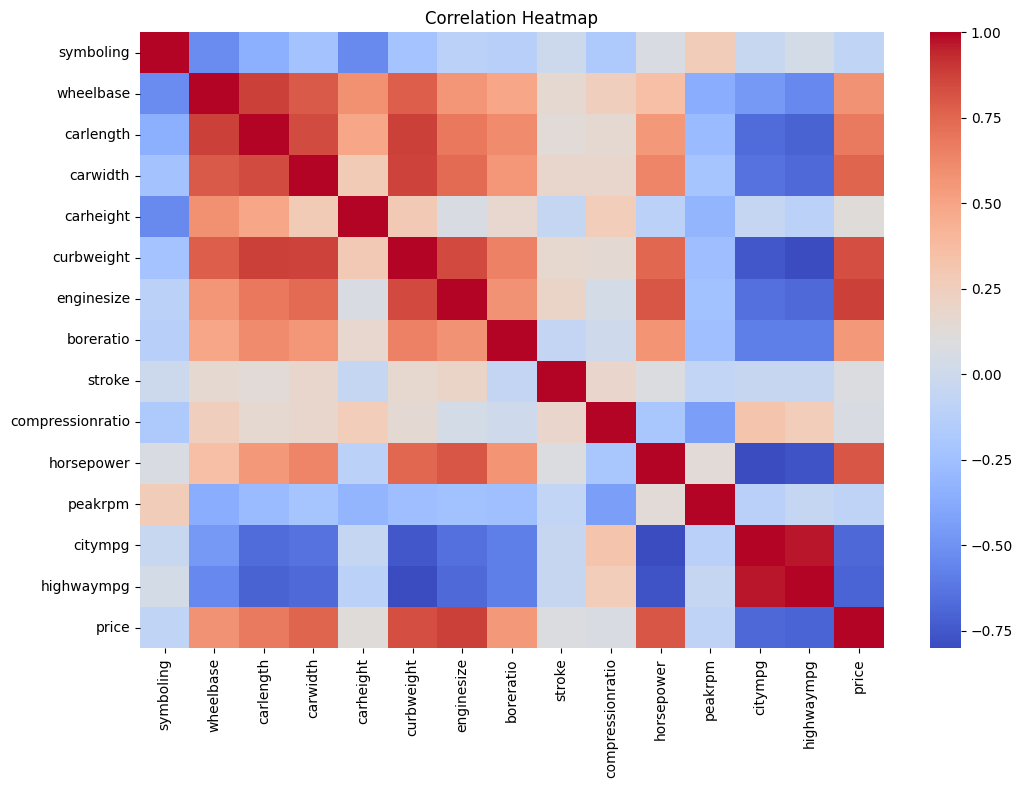

In [83]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [84]:
corr = df.corr(numeric_only=True)["price"]

print(corr.sort_values(ascending=False))

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


In [85]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [86]:
X = df.drop("price", axis=1)

y = df["price"]

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [89]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [90]:
lr_pred = lr.predict(X_test_scaled)

In [91]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("MSE :", mean_squared_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 2136.780473392205
MSE : 12575220.827585068
RMSE : 3546.155781629604
R2 : 0.840707115149927


In [92]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [93]:
rf_pred = rf.predict(X_test)

In [94]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("MSE :", mean_squared_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 :", r2_score(y_test, rf_pred))

Random Forest
MAE : 1307.6731219512199
MSE : 3522224.1624710755
RMSE : 1876.7589516160767
R2 : 0.9553832687615398


In [95]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.840707
1,Random Forest,0.955383


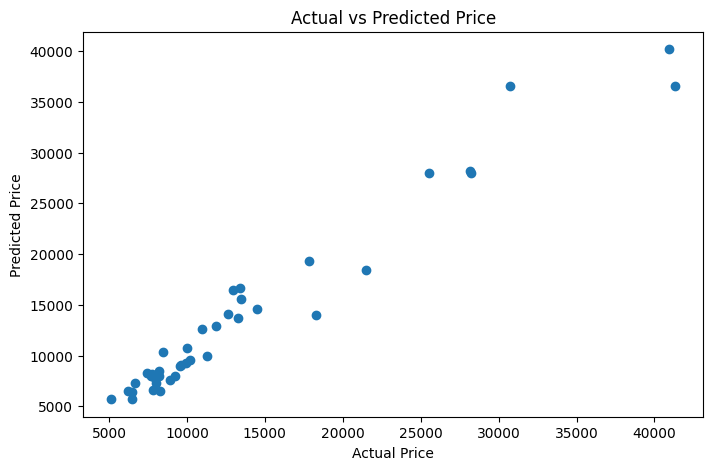

In [96]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [97]:
sample_car = X.iloc[[0]]

pred = rf.predict(sample_car)

print("Actual Price:", y.iloc[0])
print("Predicted Price:", pred[0])

Actual Price: 13495.0
Predicted Price: 14555.8
